# RL en Blackjack: Monte Carlo, SARSA y Q-Learning
## Notebook SOLVED


- El estado es:

  s = (suma del jugador,carta visible del dealer,usable ace)

- Acciones:
  -  0 = Stick
  - 1 = Hit

- Reward terminal: victoria \(+1\), empate \(0\), derrota \(-1\)


In [1]:
%pip install -q gymnasium

In [2]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

from collections import defaultdict
from functools import lru_cache

SEED = 42
rng = np.random.default_rng(SEED)

env = gym.make("Blackjack-v1", natural=False, sab=False)

In [3]:
state, _ = env.reset(seed=SEED)

print("Estado inicial:", state)
print("Acciones:", env.action_space)
print("0 = Stick | 1 = Hit")

Estado inicial: (15, 2, 0)
Acciones: Discrete(2)
0 = Stick | 1 = Hit


# Referencia de Política Óptima para evaluar los agentes \(Q^\*\)

En este Blackjack simplificado conocemos:
- la distribución de las cartas;
- las reglas del dealer;
- la dinámica exacta del juego.

Por eso podemos resolver el problema con programación dinámica y obtener:

\[
Q^\*(s,a)
\]

In [4]:
CARD_VALUES = np.array([1,2,3,4,5,6,7,8,9,10])
CARD_PROBS = np.array([1,1,1,1,1,1,1,1,1,4], dtype=float) / 13.0

def add_card(total, usable_ace, card):
    total = int(total)
    usable_ace = bool(usable_ace)

    total += card

    if card == 1 and total + 10 <= 21:
        total += 10
        usable_ace = True

    if total > 21 and usable_ace:
        total -= 10
        usable_ace = False

    return total, usable_ace

@lru_cache(None)
def dealer_finish_distribution(total, usable_ace):
    if total >= 17:
        return {22: 1.0} if total > 21 else {total: 1.0}

    out = defaultdict(float)

    for card, prob in zip(CARD_VALUES, CARD_PROBS):
        new_total, new_usable = add_card(total, usable_ace, int(card))

        if new_total > 21:
            out[22] += prob
        else:
            for outcome, p in dealer_finish_distribution(
                new_total, new_usable
            ).items():
                out[outcome] += prob * p

    return dict(out)

def initial_two_card_total(card1, card2):
    total = card1 + card2
    usable = False

    if card1 == 1 or card2 == 1:
        if total + 10 <= 21:
            total += 10
            usable = True

    return total, usable

def dealer_distribution(showing):
    out = defaultdict(float)

    for hidden, prob in zip(CARD_VALUES, CARD_PROBS):
        total, usable = initial_two_card_total(int(showing), int(hidden))

        for outcome, p in dealer_finish_distribution(
            total, usable
        ).items():
            out[outcome] += prob * p

    return dict(out)

DEALER_DISTS = {
    showing: dealer_distribution(showing)
    for showing in range(1, 11)
}

def stick_value(player_sum, dealer_showing):
    value = 0.0

    for dealer_final, prob in DEALER_DISTS[dealer_showing].items():
        if dealer_final == 22:
            reward = 1.0
        elif player_sum > dealer_final:
            reward = 1.0
        elif player_sum < dealer_final:
            reward = -1.0
        else:
            reward = 0.0

        value += prob * reward

    return value

def compute_optimal_q(tol=1e-12, max_iter=10_000):
    states = [
        (player_sum, dealer_showing, usable)
        for player_sum in range(4, 22)
        for dealer_showing in range(1, 11)
        for usable in [False, True]
    ]

    V = {state: 0.0 for state in states}

    for _ in range(max_iter):
        new_V = {}
        delta = 0.0

        for state in states:
            player_sum, dealer_showing, usable = state

            q_stick = stick_value(player_sum, dealer_showing)
            q_hit = 0.0

            for card, prob in zip(CARD_VALUES, CARD_PROBS):
                next_sum, next_usable = add_card(
                    player_sum, usable, int(card)
                )

                if next_sum > 21:
                    q_hit += prob * (-1.0)
                else:
                    q_hit += prob * V[
                        (next_sum, dealer_showing, next_usable)
                    ]

            new_V[state] = max(q_stick, q_hit)
            delta = max(delta, abs(new_V[state] - V[state]))

        V = new_V

        if delta < tol:
            break

    Q_star = {}

    for state in states:
        player_sum, dealer_showing, usable = state

        q_stick = stick_value(player_sum, dealer_showing)
        q_hit = 0.0

        for card, prob in zip(CARD_VALUES, CARD_PROBS):
            next_sum, next_usable = add_card(
                player_sum, usable, int(card)
            )

            q_hit += prob * (
                -1.0
                if next_sum > 21
                else V[(next_sum, dealer_showing, next_usable)]
            )

        Q_star[state] = np.array([q_stick, q_hit])

    return Q_star

Q_star = compute_optimal_q()

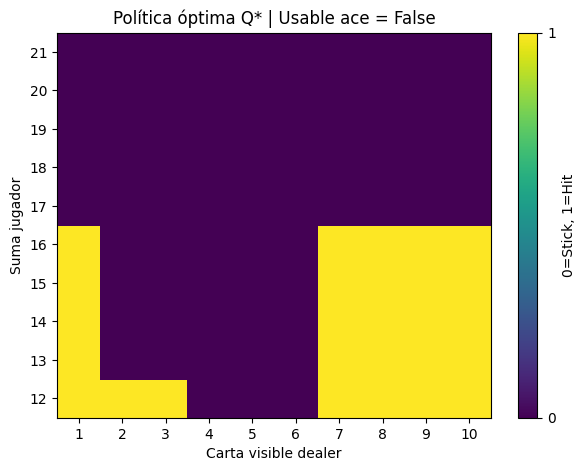

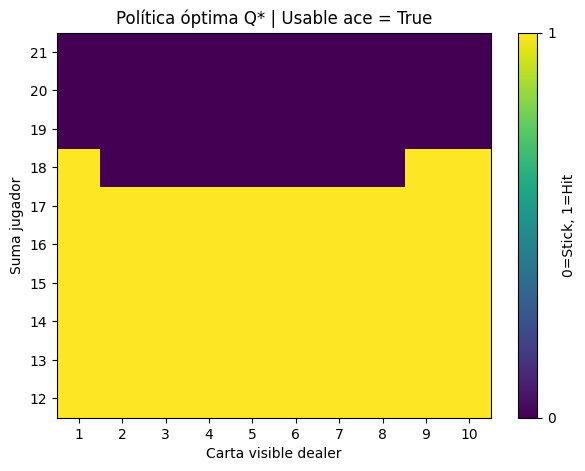

In [5]:
REFERENCE_STATES = [
    (player_sum, dealer_showing, usable)
    for player_sum in range(12, 22)
    for dealer_showing in range(1, 11)
    for usable in [False, True]
]

def optimal_decision_pct(Q, Q_star):
    correct = 0

    for state in REFERENCE_STATES:
        learned_action = int(np.argmax(Q[state]))
        q_star = Q_star[state]

        optimal_actions = np.flatnonzero(
            np.isclose(q_star, q_star.max(), atol=1e-10)
        )

        correct += int(learned_action in optimal_actions)

    return 100.0 * correct / len(REFERENCE_STATES)

def plot_policy(Q, title):
    player_sums = np.arange(12, 22)
    dealer_cards = np.arange(1, 11)

    for usable in [False, True]:
        policy = np.zeros((len(player_sums), len(dealer_cards)))

        for i, ps in enumerate(player_sums):
            for j, dc in enumerate(dealer_cards):
                policy[i, j] = np.argmax(Q[(ps, dc, usable)])

        plt.figure(figsize=(7, 5))
        plt.imshow(policy, origin="lower", aspect="auto", vmin=0, vmax=1)
        plt.title(f"{title} | Usable ace = {usable}")
        plt.xlabel("Carta visible dealer")
        plt.ylabel("Suma jugador")
        plt.xticks(np.arange(10), dealer_cards)
        plt.yticks(np.arange(10), player_sums)
        plt.colorbar(ticks=[0, 1], label="0=Stick, 1=Hit")
        plt.show()

plot_policy(Q_star, "Política óptima Q*")

## 3. Helpers y Completar ε-greedy

In [6]:
def new_q():
    return defaultdict(lambda: np.zeros(2, dtype=float))

def new_visits():
    return defaultdict(lambda: np.zeros(2, dtype=int))

def epsilon_greedy(Q, state, epsilon, rng):
    if rng.random() < epsilon:
        return int(rng.integers(2))

    q = Q[state]
    best_actions = np.flatnonzero(q == q.max())
    return int(rng.choice(best_actions))

In [7]:
def epsilon_schedule(
    episode,
    n_episodes,
    eps_start=1.0,
    eps_end=0.05,
):
    fraction = episode / max(1, n_episodes - 1)
    return eps_start + fraction * (eps_end - eps_start)

def record_checkpoint(
    history,
    Q,
    episode_rewards,
    episode,
    Q_star,
    reward_window=5_000,
):
    start = max(0, len(episode_rewards) - reward_window)
    recent_reward = np.mean(episode_rewards[start:])

    history["episode"].append(episode)
    history["train_reward"].append(recent_reward)
    history["optimal_pct"].append(
        optimal_decision_pct(Q, Q_star)
    )

def plot_learning_history(history, title):
    plt.figure(figsize=(9, 4))
    plt.plot(history["episode"], history["train_reward"])
    plt.axhline(0, linestyle="--", linewidth=1)
    plt.xlabel("Episodio")
    plt.ylabel("Reward promedio reciente")
    plt.title(f"{title} — reward durante entrenamiento")
    plt.show()

    plt.figure(figsize=(9, 4))
    plt.plot(history["episode"], history["optimal_pct"])
    plt.axhline(100, linestyle="--", linewidth=1)
    plt.ylim(0, 102)
    plt.xlabel("Episodio")
    plt.ylabel("% decisiones greedy óptimas")
    plt.title(f"{title} — agreement con Q*")
    plt.show()

def plot_visits(visits, title):
    player_sums = np.arange(12, 22)
    dealer_cards = np.arange(1, 11)

    for usable in [False, True]:
        counts = np.zeros((len(player_sums), len(dealer_cards)))

        for i, ps in enumerate(player_sums):
            for j, dc in enumerate(dealer_cards):
                counts[i, j] = visits[(ps, dc, usable)].sum()

        plt.figure(figsize=(7, 5))
        plt.imshow(np.log1p(counts), origin="lower", aspect="auto")
        plt.title(f"{title} | log(1 + visitas) | Ace={usable}")
        plt.xlabel("Carta visible dealer")
        plt.ylabel("Suma jugador")
        plt.xticks(np.arange(10), dealer_cards)
        plt.yticks(np.arange(10), player_sums)
        plt.colorbar(label="log(1 + visitas)")
        plt.show()

def print_state_details(Q, visits, states):
    for state in states:
        print(
            f"{state}: "
            f"Q(Stick)={Q[state][0]: .3f}, "
            f"Q(Hit)={Q[state][1]: .3f} | "
            f"visitas={visits[state].tolist()}"
        )

def greedy_action(Q, state):
    return int(np.argmax(Q[state]))

def evaluate_greedy(Q, n_episodes=20_000, seed=123):
    eval_env = gym.make(
        "Blackjack-v1",
        natural=False,
        sab=False,
    )

    rewards = []

    for ep in range(n_episodes):
        state, _ = eval_env.reset(seed=seed + ep)
        done = False
        total_reward = 0.0

        while not done:
            action = greedy_action(Q, state)

            state, reward, terminated, truncated, _ = (
                eval_env.step(action)
            )

            done = terminated or truncated
            total_reward += reward

        rewards.append(total_reward)

    rewards = np.asarray(rewards)

    return {
        "mean_reward": rewards.mean(),
        "win_rate": np.mean(rewards > 0),
        "draw_rate": np.mean(rewards == 0),
        "loss_rate": np.mean(rewards < 0),
    }

print("Referencia Q*:")
print("Decisiones óptimas:", optimal_decision_pct(Q_star, Q_star), "%")
print("Evaluación aproximada de la política óptima:")
print(evaluate_greedy(Q_star, n_episodes=20_000))

Referencia Q*:
Decisiones óptimas: 100.0 %
Evaluación aproximada de la política óptima:
{'mean_reward': np.float64(-0.0518), 'win_rate': np.float64(0.42795), 'draw_rate': np.float64(0.0923), 'loss_rate': np.float64(0.47975)}


# Monte Carlo (COMPLETAR)


In [8]:
def train_mc(
    n_episodes=100_000,
    gamma=1.0,
    eps_start=1.0,
    eps_end=0.05,
    eval_every=2_500,
    seed=SEED,
):
    env = gym.make("Blackjack-v1", natural=False, sab=False)
    rng = np.random.default_rng(seed)

    Q = new_q()
    visits = new_visits()
    rewards = []
    history = {
        "episode": [],
        "train_reward": [],
        "optimal_pct": [],
    }

    for ep in range(n_episodes):
        epsilon = epsilon_schedule(
            ep, n_episodes, eps_start, eps_end
        )

        state, _ = env.reset()
        done = False
        episode = []
        total_reward = 0.0

        while not done:
            action = epsilon_greedy(
                Q, state, epsilon, rng
            )

            next_state, reward, terminated, truncated, _ = (
                env.step(action)
            )

            done = terminated or truncated

            episode.append((state, action, reward))
            total_reward += reward
            state = next_state

        rewards.append(total_reward)

        for t, (state, action, _) in enumerate(episode):
            G = sum(
                (gamma ** k) * episode[t + k][2]
                for k in range(len(episode) - t)
            )

            visits[state][action] += 1
            alpha = 1.0 / visits[state][action]

            Q[state][action] += (
                alpha * (G - Q[state][action])
            )

        if (
            (ep + 1) % eval_every == 0
            or ep == n_episodes - 1
        ):
            record_checkpoint(
                history,
                Q,
                rewards,
                ep + 1,
                Q_star,
            )

    return Q, visits, rewards, history

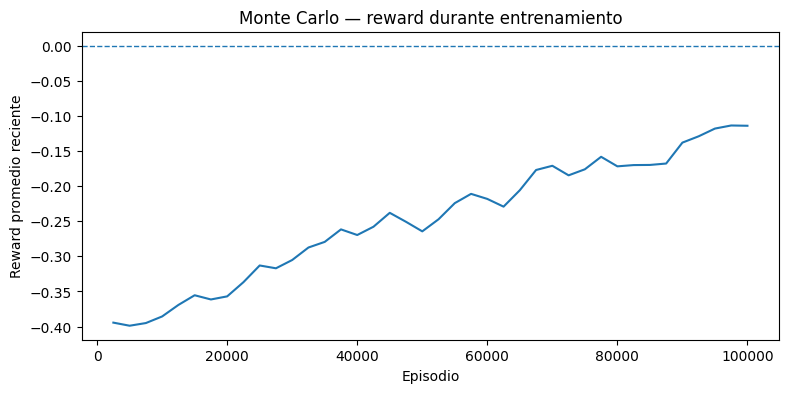

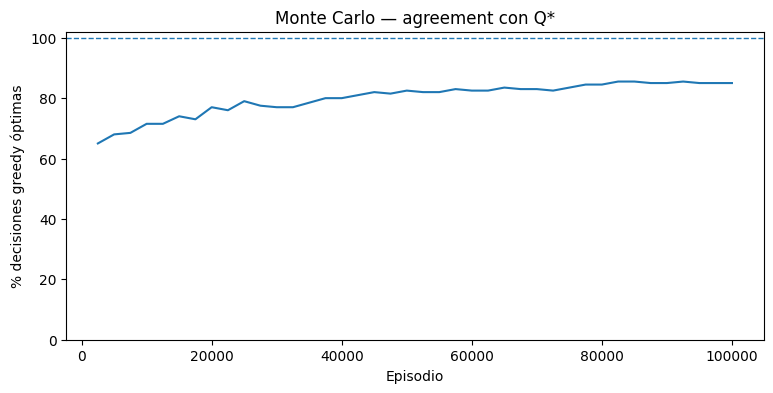

Agreement final con Q*:
85.0%

Evaluación greedy:
{'mean_reward': np.float64(-0.0793), 'win_rate': np.float64(0.42345), 'draw_rate': np.float64(0.0738), 'loss_rate': np.float64(0.50275)}


In [9]:
N_EPISODES = 100_000

Q_mc, visits_mc, rewards_mc, history_mc = train_mc(
    n_episodes=N_EPISODES,
    gamma=1.0,
    eps_start=1.0,
    eps_end=0.05,
)

plot_learning_history(history_mc, "Monte Carlo")

print("Agreement final con Q*:")
print(f"{optimal_decision_pct(Q_mc, Q_star):.1f}%")

print("\nEvaluación greedy:")
print(evaluate_greedy(Q_mc))

### Experimentar con MC

Cambiar **parámetros**, contrastar curvas y sacar conclusiones


In [10]:
# Recomendación, cambiar un parámetro a la vez para aislar efectos
MC_EXPERIMENT = {
    "n_episodes": 50_000,
    "gamma": 1.0,
    "eps_start": 1.0,
    "eps_end": 0.10,
}

# Q_mc_exp, visits_mc_exp, rewards_mc_exp, history_mc_exp = train_mc(
#     **MC_EXPERIMENT
# )
#
# plot_learning_history(history_mc_exp, "MC experimento")

### Visitas y confianza


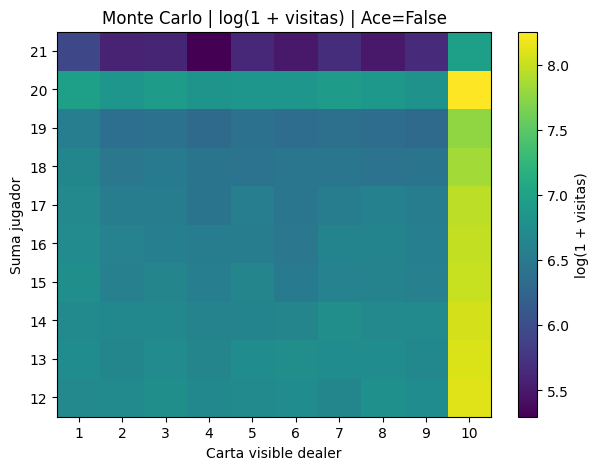

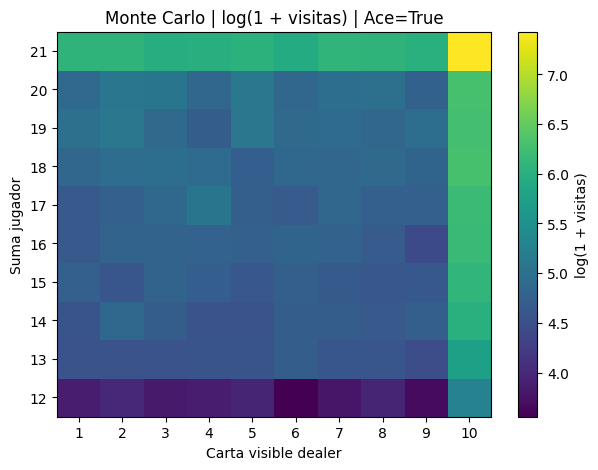

(12, 2, False): Q(Stick)=-0.376, Q(Hit)=-0.456 | visitas=[580, 241]
(16, 10, False): Q(Stick)=-0.586, Q(Hit)=-0.675 | visitas=[2111, 805]
(18, 6, False): Q(Stick)= 0.325, Q(Hit)=-0.728 | visitas=[465, 169]
(20, 10, False): Q(Stick)= 0.413, Q(Hit)=-0.891 | visitas=[2779, 1060]
(18, 6, True): Q(Stick)= 0.224, Q(Hit)=-0.032 | visitas=[98, 31]


In [11]:
plot_visits(visits_mc, "Monte Carlo")

print_state_details(
    Q_mc,
    visits_mc,
    [
        (12, 2, False),
        (16, 10, False),
        (18, 6, False),
        (20, 10, False),
        (18, 6, True),
    ],
)

# SARSA

SARSA actualiza durante el episodio.


In [12]:
def train_sarsa(
    n_episodes=100_000,
    alpha=0.05,
    gamma=1.0,
    eps_start=1.0,
    eps_end=0.05,
    eval_every=2_500,
    seed=SEED,
):
    env = gym.make("Blackjack-v1", natural=False, sab=False)
    rng = np.random.default_rng(seed)

    Q = new_q()
    visits = new_visits()
    rewards = []
    history = {
        "episode": [],
        "train_reward": [],
        "optimal_pct": [],
    }

    for ep in range(n_episodes):
        epsilon = epsilon_schedule(
            ep, n_episodes, eps_start, eps_end
        )

        state, _ = env.reset()
        action = epsilon_greedy(
            Q, state, epsilon, rng
        )

        done = False
        total_reward = 0.0

        while not done:
            next_state, reward, terminated, truncated, _ = (
                env.step(action)
            )

            done = terminated or truncated
            visits[state][action] += 1
            total_reward += reward

            if done:
                target = reward
            else:
                next_action = epsilon_greedy(
                    Q, next_state, epsilon, rng
                )

                target = (
                    reward
                    + gamma * Q[next_state][next_action]
                )

            Q[state][action] += (
                alpha * (target - Q[state][action])
            )

            if not done:
                state, action = next_state, next_action

        rewards.append(total_reward)

        if (
            (ep + 1) % eval_every == 0
            or ep == n_episodes - 1
        ):
            record_checkpoint(
                history,
                Q,
                rewards,
                ep + 1,
                Q_star,
            )

    return Q, visits, rewards, history

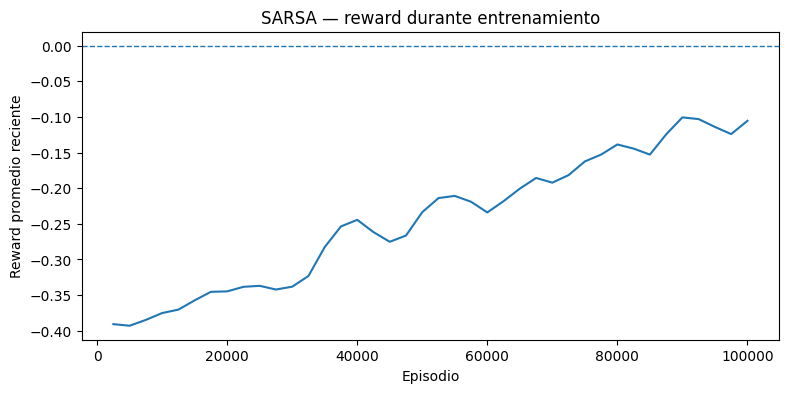

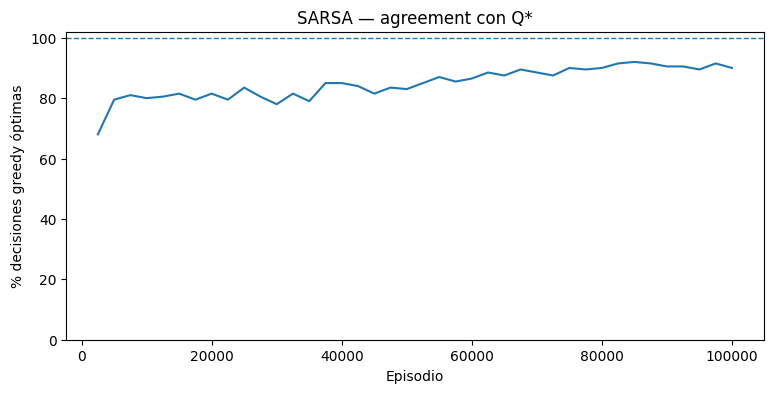

Agreement final con Q*:
90.0%

Evaluación greedy:
{'mean_reward': np.float64(-0.0747), 'win_rate': np.float64(0.4208), 'draw_rate': np.float64(0.0837), 'loss_rate': np.float64(0.4955)}


In [13]:
Q_sarsa, visits_sarsa, rewards_sarsa, history_sarsa = train_sarsa(
    n_episodes=N_EPISODES,
    alpha=0.05,
    gamma=1.0,
    eps_start=1.0,
    eps_end=0.05,
)

plot_learning_history(history_sarsa, "SARSA")

print("Agreement final con Q*:")
print(f"{optimal_decision_pct(Q_sarsa, Q_star):.1f}%")

print("\nEvaluación greedy:")
print(evaluate_greedy(Q_sarsa))

### Experimentar con SARSA


In [14]:
SARSA_EXPERIMENT = {
    "n_episodes": 50_000,
    "alpha": 0.20,
    "gamma": 1.0,
    "eps_start": 1.0,
    "eps_end": 0.05,
}

# Q_sarsa_exp, visits_sarsa_exp, rewards_sarsa_exp, history_sarsa_exp = (
#     train_sarsa(**SARSA_EXPERIMENT)
# )
#
# plot_learning_history(history_sarsa_exp, "SARSA experimento")

# Q-Learning

Q-Learning cambia una sola pieza conceptual respecto de SARSA.

In [15]:
def train_q_learning(
    n_episodes=100_000,
    alpha=0.05,
    gamma=1.0,
    eps_start=1.0,
    eps_end=0.05,
    eval_every=2_500,
    seed=SEED,
):
    env = gym.make("Blackjack-v1", natural=False, sab=False)
    rng = np.random.default_rng(seed)

    Q = new_q()
    visits = new_visits()
    rewards = []
    history = {
        "episode": [],
        "train_reward": [],
        "optimal_pct": [],
    }

    for ep in range(n_episodes):
        epsilon = epsilon_schedule(
            ep, n_episodes, eps_start, eps_end
        )

        state, _ = env.reset()
        done = False
        total_reward = 0.0

        while not done:
            action = epsilon_greedy(
                Q, state, epsilon, rng
            )

            next_state, reward, terminated, truncated, _ = (
                env.step(action)
            )

            done = terminated or truncated
            visits[state][action] += 1
            total_reward += reward

            if done:
                target = reward
            else:
                target = (
                    reward
                    + gamma * np.max(Q[next_state])
                )

            Q[state][action] += (
                alpha * (target - Q[state][action])
            )

            state = next_state

        rewards.append(total_reward)

        if (
            (ep + 1) % eval_every == 0
            or ep == n_episodes - 1
        ):
            record_checkpoint(
                history,
                Q,
                rewards,
                ep + 1,
                Q_star,
            )

    return Q, visits, rewards, history

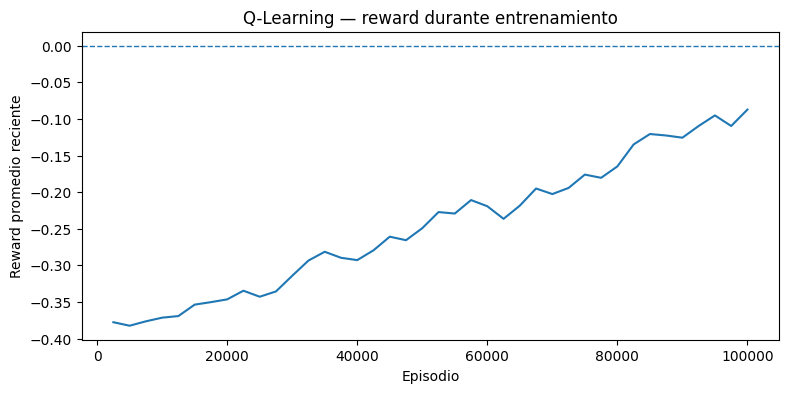

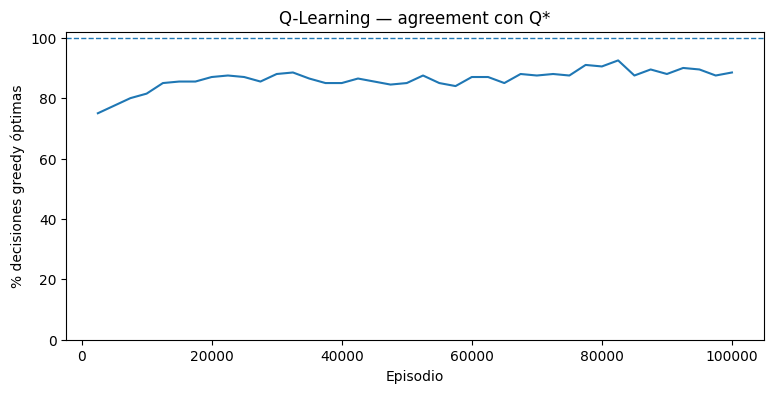

Agreement final con Q*:
88.5%

Evaluación greedy:
{'mean_reward': np.float64(-0.0762), 'win_rate': np.float64(0.4169), 'draw_rate': np.float64(0.09), 'loss_rate': np.float64(0.4931)}


In [16]:
Q_ql, visits_ql, rewards_ql, history_ql = train_q_learning(
    n_episodes=N_EPISODES,
    alpha=0.05,
    gamma=1.0,
    eps_start=1.0,
    eps_end=0.05,
)

plot_learning_history(history_ql, "Q-Learning")

print("Agreement final con Q*:")
print(f"{optimal_decision_pct(Q_ql, Q_star):.1f}%")

print("\nEvaluación greedy:")
print(evaluate_greedy(Q_ql))

### Experimentar con Q-Learning


In [17]:
QL_EXPERIMENT = {
    "n_episodes": 50_000,
    "alpha": 0.01,
    "gamma": 1.0,
    "eps_start": 1.0,
    "eps_end": 0.05,
}

# Q_ql_exp, visits_ql_exp, rewards_ql_exp, history_ql_exp = (
#     train_q_learning(**QL_EXPERIMENT)
# )
#
# plot_learning_history(history_ql_exp, "Q-Learning experimento")

# Comparación final

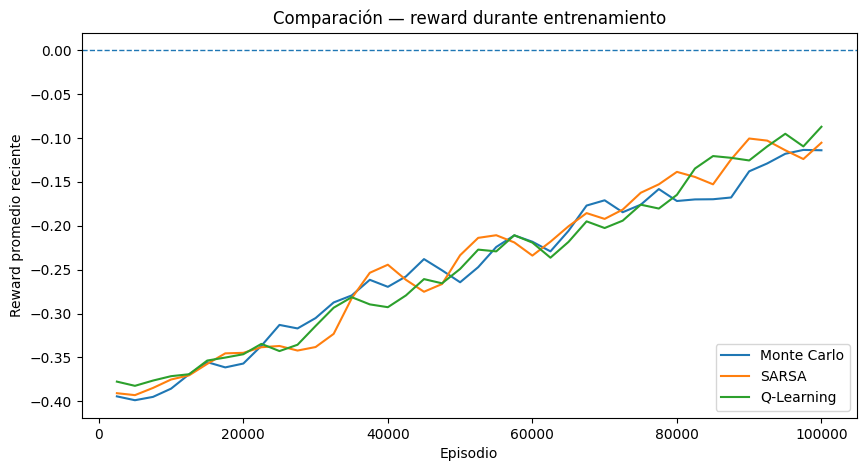

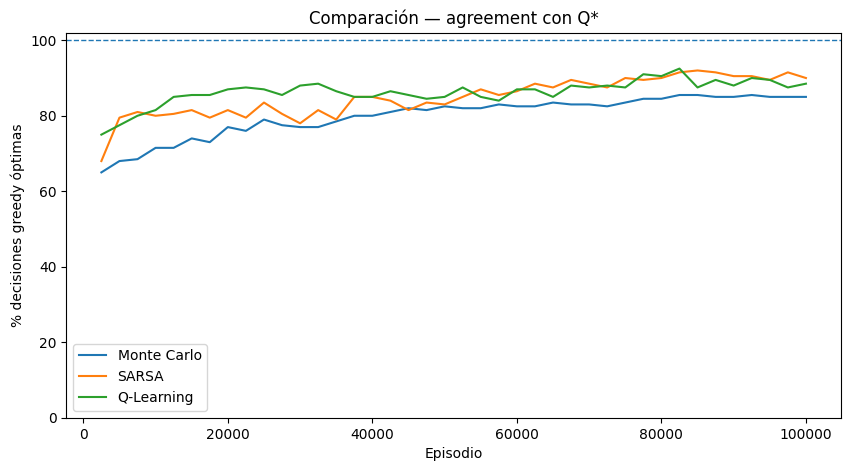

In [18]:
histories = {
    "Monte Carlo": history_mc,
    "SARSA": history_sarsa,
    "Q-Learning": history_ql,
}

plt.figure(figsize=(10, 5))
for name, history in histories.items():
    plt.plot(
        history["episode"],
        history["train_reward"],
        label=name,
    )

plt.axhline(0, linestyle="--", linewidth=1)
plt.xlabel("Episodio")
plt.ylabel("Reward promedio reciente")
plt.title("Comparación — reward durante entrenamiento")
plt.legend()
plt.show()

plt.figure(figsize=(10, 5))
for name, history in histories.items():
    plt.plot(
        history["episode"],
        history["optimal_pct"],
        label=name,
    )

plt.axhline(100, linestyle="--", linewidth=1)
plt.ylim(0, 102)
plt.xlabel("Episodio")
plt.ylabel("% decisiones greedy óptimas")
plt.title("Comparación — agreement con Q*")
plt.legend()
plt.show()

In [19]:
models = {
    "Monte Carlo": Q_mc,
    "SARSA": Q_sarsa,
    "Q-Learning": Q_ql,
    "Q*": Q_star,
}

for name, Q in models.items():
    result = evaluate_greedy(Q, n_episodes=20_000)

    print(
        f"{name:12s} | "
        f"optimal={optimal_decision_pct(Q, Q_star):6.1f}% | "
        f"mean_reward={result['mean_reward']:+.4f} | "
        f"win={result['win_rate']:.3f}"
    )

Monte Carlo  | optimal=  85.0% | mean_reward=-0.0793 | win=0.423
SARSA        | optimal=  90.0% | mean_reward=-0.0747 | win=0.421
Q-Learning   | optimal=  88.5% | mean_reward=-0.0762 | win=0.417
Q*           | optimal= 100.0% | mean_reward=-0.0518 | win=0.428


## Preguntas

- Cuál aprende decisiones óptimas más rápido o antes?
- Tiene el algoritmo con mayor % de decisiones óptimas mejor reward siempre? Por qué?
- Por qué no esperamos reward promedio \(+1\) ni siquiera para \(Q^\*\)?
- Qué diferencia fundamental hay entre aprender buenos valores \(Q\) y aprender una buena política?